In [2]:
!pip install -U scikit-learn


  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl (36.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# # Analysis of JOSS Language Dependencies CSV
# Split rows with actual dependencies into 70% training and 30% testing

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the CSV file
df = pd.read_csv(r"c:\Users\eggoni\Desktop\llm\joss_all_language_depends.csv")
print(f"Total rows in CSV: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Filter rows that have non-empty, non-null, and non-empty-list dependecies_found
df_with_deps = df[
    df['dependecies_found'].notna() &
    (df['dependecies_found'].str.strip() != '') &
    (df['dependecies_found'].str.strip() != '[]')
]
print(f"Rows with actual dependencies: {len(df_with_deps)}")
print(f"Rows without actual dependencies: {len(df) - len(df_with_deps)}")

# Split into 70% training and 30% testing
train_df, test_df = train_test_split(df_with_deps, test_size=0.3, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

# Save to separate CSV files
train_df.to_csv(r"c:\Users\eggoni\Desktop\llm\train_dependencies.csv", index=False)
test_df.to_csv(r"c:\Users\eggoni\Desktop\llm\test_dependencies.csv", index=False)
print("Saved training data to: c:\\Users\\eggoni\\Desktop\\llm\\train_dependencies.csv")
print("Saved testing data to: c:\\Users\\eggoni\\Desktop\\llm\\test_dependencies.csv")

# Summary
print("\n--- Training Set Summary ---")
print(f"Shape: {train_df.shape}")
print(f"Languages:\n{train_df['Language'].value_counts()}")

print("\n--- Testing Set Summary ---")
print(f"Shape: {test_df.shape}")
print(f"Languages:\n{test_df['Language'].value_counts()}")

Total rows in CSV: 3199
Columns: ['status', 'paper_url', 'issue_url', 'doi', 'joss_id', 'title', 'html_url', 'Repository Name', 'Full Name', 'Description', 'Stars', 'Forks', 'Issues', 'Watchers', 'Language', 'License', 'Created Date', 'Updated Date', 'Pushed Date', 'Default Branch', 'Size', 'Contributors', 'Number of Contributors', 'Total Downloads', 'requirements_defined', 'dependecies_found']
Rows with actual dependencies: 1576
Rows without actual dependencies: 1623
Training set size: 1103
Testing set size: 473
Saved training data to: c:\Users\eggoni\Desktop\llm\train_dependencies.csv
Saved testing data to: c:\Users\eggoni\Desktop\llm\test_dependencies.csv

--- Training Set Summary ---
Shape: (1103, 26)
Languages:
Language
Python    712
R         292
C++        85
C          11
Name: count, dtype: int64

--- Testing Set Summary ---
Shape: (473, 26)
Languages:
Language
Python              330
R                    99
C++                  39
C                     3
Jupyter Notebook     

In [7]:
# Load the labels CSV that contains dependency_labels as ground truth
labels_df = pd.read_csv(r"c:\Users\eggoni\Desktop\llm\joss_all_with_dependency_labels1.csv")
print(f"Labels CSV columns: {list(labels_df.columns)}")
print(f"Labels CSV rows: {len(labels_df)}")

# Keep only joss_id and dependency_labels columns for merging
labels_mapping = labels_df[['joss_id', 'dependency_labels']].dropna(subset=['dependency_labels'])
labels_mapping = labels_mapping.drop_duplicates(subset=['joss_id'])
print(f"Rows with dependency_labels: {len(labels_mapping)}")

# Merge ground truth labels into train and test DataFrames
train_df_labeled = train_df.merge(labels_mapping, on='joss_id', how='left')
test_df_labeled = test_df.merge(labels_mapping, on='joss_id', how='left')

# Check how many got labels
print(f"\n--- Training Set ---")
print(f"Total rows: {len(train_df_labeled)}")
print(f"Rows WITH dependency_labels (ground truth): {train_df_labeled['dependency_labels'].notna().sum()}")
print(f"Rows WITHOUT dependency_labels: {train_df_labeled['dependency_labels'].isna().sum()}")

print(f"\n--- Testing Set ---")
print(f"Total rows: {len(test_df_labeled)}")
print(f"Rows WITH dependency_labels (ground truth): {test_df_labeled['dependency_labels'].notna().sum()}")
print(f"Rows WITHOUT dependency_labels: {test_df_labeled['dependency_labels'].isna().sum()}")

# Save updated CSVs with ground truth labels
train_df_labeled.to_csv(r"c:\Users\eggoni\Desktop\llm\train_dependencies.csv", index=False)
test_df_labeled.to_csv(r"c:\Users\eggoni\Desktop\llm\test_dependencies.csv", index=False)
print("\n✅ Saved train_dependencies.csv and test_dependencies.csv with dependency_labels (ground truth)")

# Preview
print("\n--- Sample ground truth labels (Training) ---")
print(train_df_labeled[['joss_id', 'Language', 'dependency_labels']].head())

Labels CSV columns: ['status', 'paper_url', 'issue_url', 'doi', 'joss_id', 'title', 'html_url', 'Repository Name', 'Full Name', 'Description', 'Stars', 'Forks', 'Issues', 'Watchers', 'Language', 'License', 'Created Date', 'Updated Date', 'Pushed Date', 'Default Branch', 'Size', 'Contributors', 'Number of Contributors', 'Total Downloads', 'requirements_defined', 'dependency_labels', 'dependecies_found']
Labels CSV rows: 1559
Rows with dependency_labels: 1559

--- Training Set ---
Total rows: 1103
Rows WITH dependency_labels (ground truth): 1089
Rows WITHOUT dependency_labels: 14

--- Testing Set ---
Total rows: 473
Rows WITH dependency_labels (ground truth): 470
Rows WITHOUT dependency_labels: 3

✅ Saved train_dependencies.csv and test_dependencies.csv with dependency_labels (ground truth)

--- Sample ground truth labels (Training) ---
   joss_id Language                                  dependency_labels
0   1808.0   Python     ['Modeling And Simulation', 'Ris', 'Software']
1    624.0 

In [1]:
"""Compare results from multiple models on the same test set."""

import ast
import pandas as pd
from pathlib import Path
from metrics import calculate_metrics, per_label_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def parse_list(raw):
    if not isinstance(raw, str) or not raw.strip():
        return []
    try:
        val = ast.literal_eval(raw)
        if isinstance(val, (list, tuple)):
            return [str(x).strip() for x in val if str(x).strip()]
    except (ValueError, SyntaxError):
        pass
    return []

def evaluate_file(csv_path, model_name):
    df = pd.read_csv(csv_path)
    df["pred"] = df["predicted_categories"].apply(parse_list)
    df["gt"] = df["ground_truth"].apply(parse_list)
    
    mask = (df["success"] == True) & (df["gt"].apply(len) > 0) & (df["pred"].apply(len) > 0)
    df_eval = df[mask]
    failed = len(df) - len(df_eval)
    
    preds = df_eval["pred"].tolist()
    gts = df_eval["gt"].tolist()
    
    metrics = calculate_metrics(preds, gts)
    report = per_label_report(preds, gts)
    
    return {
        "model": model_name,
        "total": len(df),
        "evaluated": len(df_eval),
        "failed": failed,
        "metrics": metrics,
        "report": report,
        "avg_pred_labels": sum(len(p) for p in preds) / len(preds),
        "avg_gt_labels": sum(len(g) for g in gts) / len(gts),
    }

def main():
    models = {
        "llama3.3:70b": Path("test_results.csv"),
        "gemma3:27b": Path("test_results_gemma3_27b.csv"),
    }
    
    results = {}
    for name, path in models.items():
        if not path.exists():
            print(f"⚠ {path} not found, skipping {name}")
            continue
        results[name] = evaluate_file(path, name)
        print(f"✅ Loaded {name}: {results[name]['evaluated']} evaluated, {results[name]['failed']} failed")

    # ── Overall Comparison ──
    print(f"\n{'='*80}")
    print(f"  MODEL COMPARISON — Overall Metrics")
    print(f"{'='*80}")
    print(f"  {'Metric':<25}", end="")
    for name in results:
        print(f"  {name:>18}", end="")
    print(f"  {'Winner':>10}")
    print(f"  {'-'*75}")

    metric_keys = [
        ("Evaluated", "evaluated"),
        ("Failed", "failed"),
        ("Avg Pred Labels", "avg_pred_labels"),
        ("Avg GT Labels", "avg_gt_labels"),
    ]
    for display, key in metric_keys:
        print(f"  {display:<25}", end="")
        vals = {}
        for name, r in results.items():
            v = r[key]
            vals[name] = v
            print(f"  {v:>18.2f}" if isinstance(v, float) else f"  {v:>18}", end="")
        print()

    metric_keys2 = [
        ("Jaccard", "jaccard_similarity"),
        ("Precision", "precision"),
        ("Recall", "recall"),
        ("F1 Score", "f1_score"),
        ("Exact Match", "exact_match_ratio"),
        ("Hamming Loss", "hamming_loss"),
        ("Micro F1", "micro_f1"),
        ("Macro F1", "macro_f1"),
    ]
    for display, key in metric_keys2:
        print(f"  {display:<25}", end="")
        vals = {}
        for name, r in results.items():
            v = r["metrics"].get(key, 0)
            vals[name] = v
            print(f"  {v:>18.4f}", end="")
        # Winner (higher is better, except hamming_loss)
        if vals:
            if key == "hamming_loss":
                winner = min(vals, key=vals.get)
            else:
                winner = max(vals, key=vals.get)
            short = winner.split(":")[0]
            print(f"  {'← ' + short:>10}", end="")
        print()

    # ── Per-Label Comparison ──
    print(f"\n{'='*80}")
    print(f"  MODEL COMPARISON — Per-Label F1 Scores")
    print(f"{'='*80}")
    print(f"  {'Category':<28}", end="")
    for name in results:
        print(f"  {name:>15}", end="")
    print(f"  {'Δ':>8}  {'Winner':>10}")
    print(f"  {'-'*75}")

    all_labels = set()
    for r in results.values():
        all_labels.update(r["report"].keys())

    model_names = list(results.keys())
    for label in sorted(all_labels, key=lambda l: -max(r["report"].get(l, {}).get("support", 0) for r in results.values())):
        print(f"  {label:<28}", end="")
        f1s = {}
        for name in model_names:
            f1 = results[name]["report"].get(label, {}).get("f1", 0)
            f1s[name] = f1
            print(f"  {f1:>15.3f}", end="")
        
        if len(f1s) == 2:
            vals = list(f1s.values())
            delta = vals[0] - vals[1]
            winner = max(f1s, key=f1s.get).split(":")[0]
            print(f"  {delta:>+8.3f}  {'← ' + winner:>10}", end="")
        print()

    # ── Per-Label Detail ──
    print(f"\n{'='*80}")
    print(f"  DETAILED: Precision / Recall per label")
    print(f"{'='*80}")
    for label in sorted(all_labels, key=lambda l: -max(r["report"].get(l, {}).get("support", 0) for r in results.values())):
        print(f"\n  {label} (support={max(r['report'].get(label, {}).get('support', 0) for r in results.values())}):")
        for name in model_names:
            s = results[name]["report"].get(label, {})
            print(f"    {name:<20} P={s.get('precision',0):.3f}  R={s.get('recall',0):.3f}  F1={s.get('f1',0):.3f}")

    print(f"\n{'='*80}")
    print(f"  RECOMMENDATION: Use the model with higher Micro F1 + Macro F1")
    for name, r in results.items():
        score = r["metrics"].get("micro_f1", 0) + r["metrics"].get("macro_f1", 0)
        print(f"    {name}: Micro F1 + Macro F1 = {score:.4f}")
    best = max(results, key=lambda n: results[n]["metrics"].get("micro_f1", 0) + results[n]["metrics"].get("macro_f1", 0))
    print(f"  → Best model: {best}")
    print(f"{'='*80}")

    # ── Overall sample-level metrics ──────────────────────────────────────────────
    overall = pd.DataFrame({
        "Metric":    ["Precision", "Recall", "F1 (Micro)", "F1 (Macro)", "Jaccard", "Hamming Loss"],
        "LLaMA 3.3 70b": [0.7864, 0.8165, 0.8018, 0.5999, 0.6624, 0.2019],
        "CatBoost":      [0.9980, 0.8834, 0.9373, 0.9119, 0.8819, 0.1548],
    })

    # ── Per-label metrics ─────────────────────────────────────────────────────────
    llama_per = pd.read_csv(r"c:\Users\eggoni\Desktop\llm\per_label_metrics_30pct.csv")
    llama_per["Category"] = llama_per["Category"].str.strip()

    cat_per = pd.DataFrame({
        "Category":  ["Process", "Modeling And Simulation", "Data Analytics",
                      "Software Analytics", "Ui", "Software", "Ris", "Hardware",
                      "Integrative Analysis"],
        "Precision": [1.00, 1.00, 1.00, 0.99, 0.99, 1.00, 1.00, 1.00, 0.88],
        "Recall":    [0.95, 0.92, 0.89, 0.90, 0.88, 0.85, 0.85, 0.79, 0.64],
        "F1 Score":  [0.98, 0.96, 0.94, 0.94, 0.94, 0.92, 0.92, 0.88, 0.74],
    })

    # Align labels — use CSV order as master
    labels_order = llama_per["Category"].str.strip().tolist()
    llama_per = llama_per.set_index("Category").reindex(labels_order).reset_index()
    cat_per   = cat_per.set_index("Category").reindex(labels_order).reset_index()

    # ── Color palette ─────────────────────────────────────────────────────────────
    C_LLAMA = "#4C72B0"   # steel blue
    C_CAT   = "#2CA02C"   # green
    plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                         "axes.spines.right": False, "axes.grid": True,
                         "grid.alpha": 0.3, "grid.linestyle": "--"})

    # ── Plot 1 – Overall metrics bar chart ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(overall))
    w = 0.35
    bars1 = ax.bar(x - w/2, overall["LLaMA 3.3 70b"], w, label="LLaMA 3.3 70b",
                   color=C_LLAMA, edgecolor="white", linewidth=0.8)
    bars2 = ax.bar(x + w/2, overall["CatBoost"],      w, label="CatBoost",
                   color=C_CAT,   edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(overall["Metric"], rotation=15, ha="right", fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Overall Model Comparison – LLaMA 3.3 70b vs CatBoost\n(30 % hold-out · 461 / 390 samples)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=11)
    for bar in [*bars1, *bars2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="bold", color="#333333")
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\overall_comparison.png", dpi=150)
    plt.show()

    # ── Plot 2 – Per-label F1 comparison ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(labels_order))
    w = 0.35
    b1 = ax.bar(x - w/2, llama_per["F1 Score"], w, label="LLaMA 3.3 70b",
                color=C_LLAMA, edgecolor="white")
    b2 = ax.bar(x + w/2, cat_per["F1 Score"],   w, label="CatBoost",
                color=C_CAT,   edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels_order, rotation=28, ha="right", fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_title("Per-Label F1 Score – LLaMA 3.3 70b vs CatBoost",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7.5)
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\perlabel_f1_comparison.png", dpi=150)
    plt.show()

    # ── Plot 3 – Per-label Precision & Recall side by side ───────────────────────
    METRIC_COLORS = {"Precision": ("#1F77B4", "#FF7F0E"), "Recall": ("#9467BD", "#E377C2")}
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ax, metric in zip(axes, ["Precision", "Recall"]):
        c1, c2 = METRIC_COLORS[metric]
        x = np.arange(len(labels_order))
        ax.bar(x - w/2, llama_per[metric], w, label="LLaMA 3.3 70b", color=c1, edgecolor="white")
        ax.bar(x + w/2, cat_per[metric],   w, label="CatBoost",      color=c2, edgecolor="white")
        ax.set_xticks(x)
        ax.set_xticklabels(labels_order, rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 1.18)
        ax.set_title(f"Per-Label {metric}", fontsize=12, fontweight="bold")
        ax.set_ylabel(metric, fontsize=11)
        ax.legend(fontsize=10)
    fig.suptitle("Per-Label Precision & Recall – LLaMA 3.3 70b vs CatBoost",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\perlabel_prec_rec_comparison.png", dpi=150)
    plt.show()

    # ── Plot 4 – Radar chart ──────────────────────────────────────────────────────
    radar_metrics = ["Precision", "Recall", "F1 (Micro)", "F1 (Macro)", "Jaccard"]
    llama_vals = overall.set_index("Metric").loc[radar_metrics, "LLaMA 3.3 70b"].tolist()
    cat_vals   = overall.set_index("Metric").loc[radar_metrics, "CatBoost"].tolist()
    angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
    llama_vals += llama_vals[:1]; cat_vals += cat_vals[:1]; angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
    ax.plot(angles, llama_vals, "o-", linewidth=2.2, label="LLaMA 3.3 70b", color=C_LLAMA)
    ax.fill(angles, llama_vals, alpha=0.18, color=C_LLAMA)
    ax.plot(angles, cat_vals,   "s-", linewidth=2.2, label="CatBoost",      color=C_CAT)
    ax.fill(angles, cat_vals,   alpha=0.18, color=C_CAT)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8, color="grey")
    ax.set_title("Radar Chart – Overall Metrics", fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\radar_comparison.png", dpi=150)
    plt.show()

    print("All plots saved to Desktop/llm/")


if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'matplotlib'

In [2]:
!pip install matplotlib pandas numpy

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.1 MB 3.2 MB/s eta 0:00:02
   ----------------- --------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Loaded llama3.3:70b: 443 evaluated, 18 failed
✅ Loaded gemma3:27b: 460 evaluated, 1 failed

  MODEL COMPARISON — Overall Metrics
  Metric                           llama3.3:70b          gemma3:27b      Winner
  ---------------------------------------------------------------------------
  Evaluated                                 443                 460
  Failed                                     18                   1
  Avg Pred Labels                          4.58                4.40
  Avg GT Labels                            4.58                4.56
  Jaccard                                0.6624              0.6340  ← llama3.3
  Precision                              0.7864              0.7770  ← llama3.3
  Recall                                 0.8165              0.7797  ← llama3.3
  F1 Score                               0.7744              0.7519  ← llama3.3
  Exact Match                            0.1219              0.1022  ← llama3.3
  Hamming Loss                         

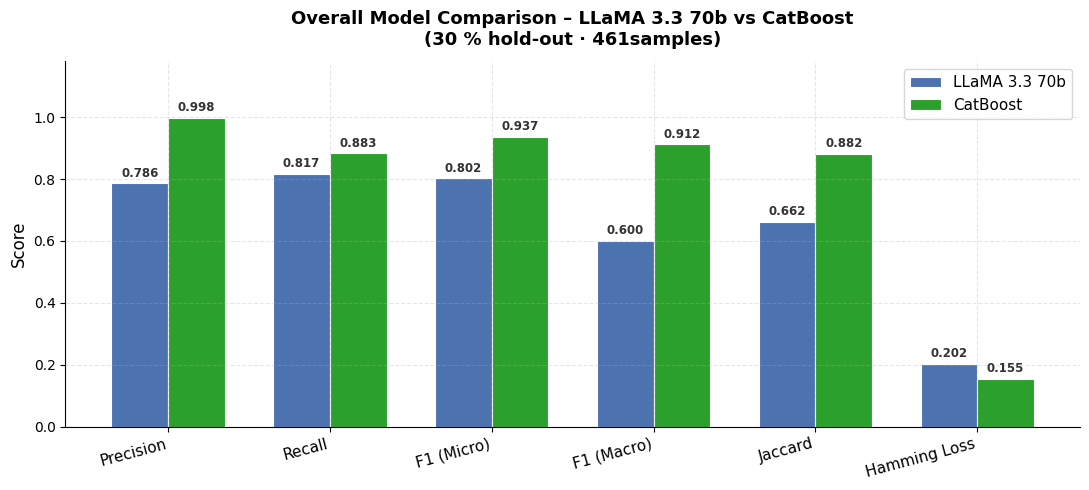

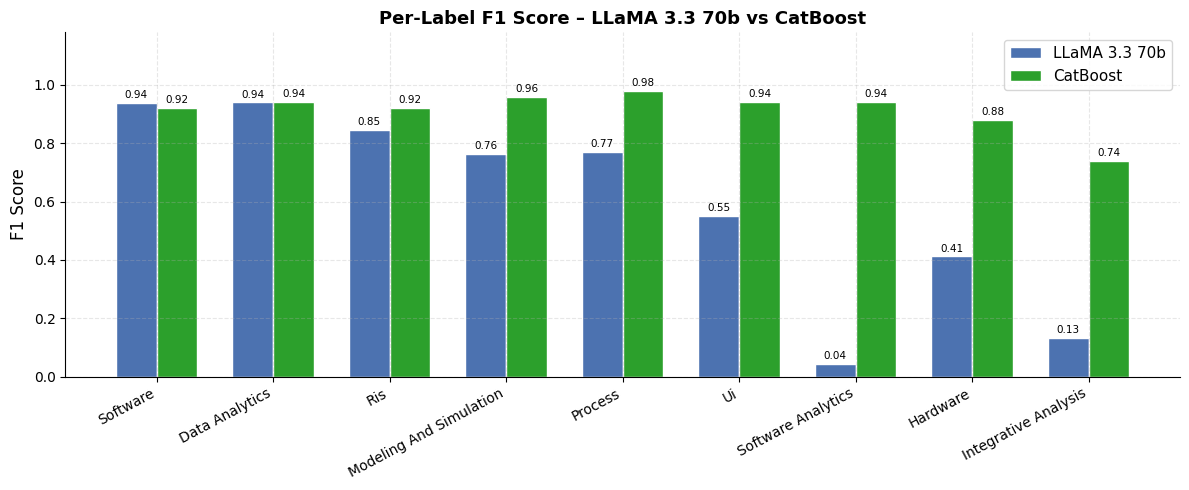

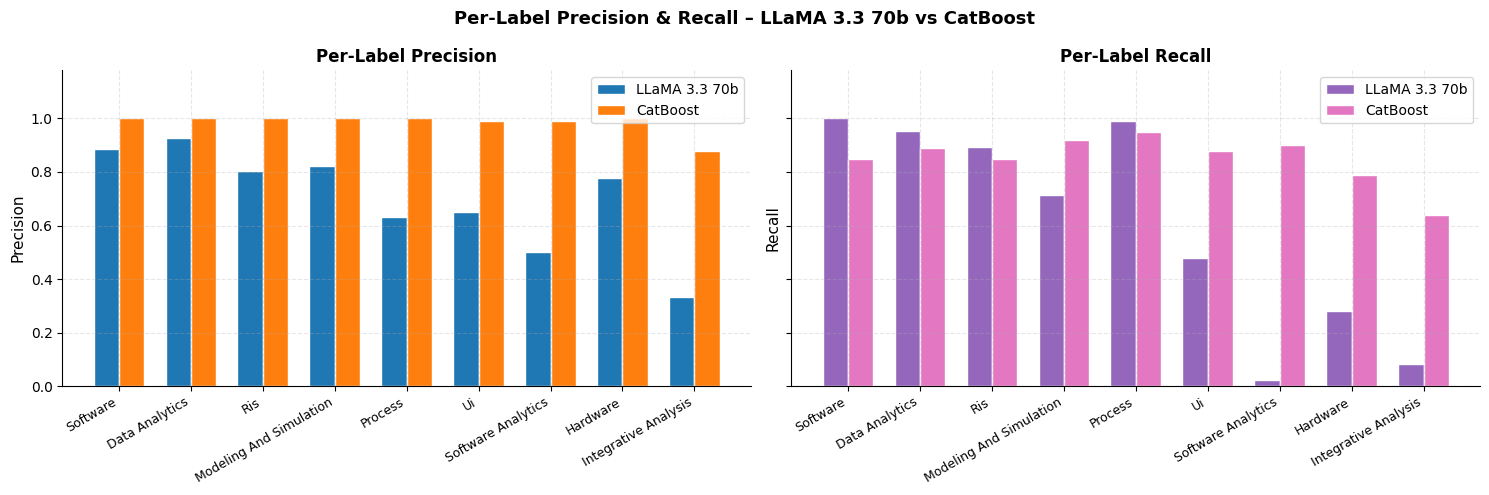

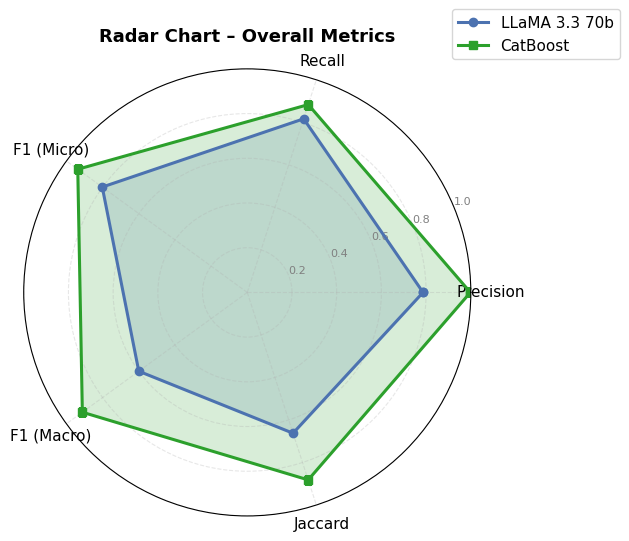

All plots saved to Desktop/llm/


In [22]:
"""Compare results from multiple models on the same test set."""

import ast
import pandas as pd
from pathlib import Path
from metrics import calculate_metrics, per_label_report
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def parse_list(raw):
    if not isinstance(raw, str) or not raw.strip():
        return []
    try:
        val = ast.literal_eval(raw)
        if isinstance(val, (list, tuple)):
            return [str(x).strip() for x in val if str(x).strip()]
    except (ValueError, SyntaxError):
        pass
    return []

def evaluate_file(csv_path, model_name):
    df = pd.read_csv(csv_path)
    df["pred"] = df["predicted_categories"].apply(parse_list)
    df["gt"] = df["ground_truth"].apply(parse_list)
    
    mask = (df["success"] == True) & (df["gt"].apply(len) > 0) & (df["pred"].apply(len) > 0)
    df_eval = df[mask]
    failed = len(df) - len(df_eval)
    
    preds = df_eval["pred"].tolist()
    gts = df_eval["gt"].tolist()
    
    metrics = calculate_metrics(preds, gts)
    report = per_label_report(preds, gts)
    
    return {
        "model": model_name,
        "total": len(df),
        "evaluated": len(df_eval),
        "failed": failed,
        "metrics": metrics,
        "report": report,
        "avg_pred_labels": sum(len(p) for p in preds) / len(preds),
        "avg_gt_labels": sum(len(g) for g in gts) / len(gts),
    }

def main():
    models = {
        "llama3.3:70b": Path("test_results.csv"),
        "gemma3:27b": Path("test_results_gemma3_27b.csv"),
    }
    
    results = {}
    for name, path in models.items():
        if not path.exists():
            print(f"⚠ {path} not found, skipping {name}")
            continue
        results[name] = evaluate_file(path, name)
        print(f"✅ Loaded {name}: {results[name]['evaluated']} evaluated, {results[name]['failed']} failed")

    # ── Overall Comparison ──
    print(f"\n{'='*80}")
    print(f"  MODEL COMPARISON — Overall Metrics")
    print(f"{'='*80}")
    print(f"  {'Metric':<25}", end="")
    for name in results:
        print(f"  {name:>18}", end="")
    print(f"  {'Winner':>10}")
    print(f"  {'-'*75}")

    metric_keys = [
        ("Evaluated", "evaluated"),
        ("Failed", "failed"),
        ("Avg Pred Labels", "avg_pred_labels"),
        ("Avg GT Labels", "avg_gt_labels"),
    ]
    for display, key in metric_keys:
        print(f"  {display:<25}", end="")
        vals = {}
        for name, r in results.items():
            v = r[key]
            vals[name] = v
            print(f"  {v:>18.2f}" if isinstance(v, float) else f"  {v:>18}", end="")
        print()

    metric_keys2 = [
        ("Jaccard", "jaccard_similarity"),
        ("Precision", "precision"),
        ("Recall", "recall"),
        ("F1 Score", "f1_score"),
        ("Exact Match", "exact_match_ratio"),
        ("Hamming Loss", "hamming_loss"),
        ("Micro F1", "micro_f1"),
        ("Macro F1", "macro_f1"),
    ]
    for display, key in metric_keys2:
        print(f"  {display:<25}", end="")
        vals = {}
        for name, r in results.items():
            v = r["metrics"].get(key, 0)
            vals[name] = v
            print(f"  {v:>18.4f}", end="")
        # Winner (higher is better, except hamming_loss)
        if vals:
            if key == "hamming_loss":
                winner = min(vals, key=vals.get)
            else:
                winner = max(vals, key=vals.get)
            short = winner.split(":")[0]
            print(f"  {'← ' + short:>10}", end="")
        print()

    # ── Per-Label Comparison ──
    print(f"\n{'='*80}")
    print(f"  MODEL COMPARISON — Per-Label F1 Scores")
    print(f"{'='*80}")
    print(f"  {'Category':<28}", end="")
    for name in results:
        print(f"  {name:>15}", end="")
    print(f"  {'Δ':>8}  {'Winner':>10}")
    print(f"  {'-'*75}")

    all_labels = set()
    for r in results.values():
        all_labels.update(r["report"].keys())

    model_names = list(results.keys())
    for label in sorted(all_labels, key=lambda l: -max(r["report"].get(l, {}).get("support", 0) for r in results.values())):
        print(f"  {label:<28}", end="")
        f1s = {}
        for name in model_names:
            f1 = results[name]["report"].get(label, {}).get("f1", 0)
            f1s[name] = f1
            print(f"  {f1:>15.3f}", end="")
        
        if len(f1s) == 2:
            vals = list(f1s.values())
            delta = vals[0] - vals[1]
            winner = max(f1s, key=f1s.get).split(":")[0]
            print(f"  {delta:>+8.3f}  {'← ' + winner:>10}", end="")
        print()

    # ── Per-Label Detail ──
    print(f"\n{'='*80}")
    print(f"  DETAILED: Precision / Recall per label")
    print(f"{'='*80}")
    for label in sorted(all_labels, key=lambda l: -max(r["report"].get(l, {}).get("support", 0) for r in results.values())):
        print(f"\n  {label} (support={max(r['report'].get(label, {}).get('support', 0) for r in results.values())}):")
        for name in model_names:
            s = results[name]["report"].get(label, {})
            print(f"    {name:<20} P={s.get('precision',0):.3f}  R={s.get('recall',0):.3f}  F1={s.get('f1',0):.3f}")

    print(f"\n{'='*80}")
    print(f"  RECOMMENDATION: Use the model with higher Micro F1 + Macro F1")
    for name, r in results.items():
        score = r["metrics"].get("micro_f1", 0) + r["metrics"].get("macro_f1", 0)
        print(f"    {name}: Micro F1 + Macro F1 = {score:.4f}")
    best = max(results, key=lambda n: results[n]["metrics"].get("micro_f1", 0) + results[n]["metrics"].get("macro_f1", 0))
    print(f"  → Best model: {best}")
    print(f"{'='*80}")

    # ── Overall sample-level metrics ──────────────────────────────────────────────
    overall = pd.DataFrame({
        "Metric":    ["Precision", "Recall", "F1 (Micro)", "F1 (Macro)", "Jaccard", "Hamming Loss"],
        "LLaMA 3.3 70b": [0.7864, 0.8165, 0.8018, 0.5999, 0.6624, 0.2019],
        "CatBoost":      [0.9980, 0.8834, 0.9373, 0.9119, 0.8819, 0.1548],
    })

    # ── Per-label metrics ─────────────────────────────────────────────────────────
    llama_per = pd.read_csv(r"c:\Users\eggoni\Desktop\llm\per_label_metrics_30pct.csv")
    llama_per["Category"] = llama_per["Category"].str.strip()

    cat_per = pd.DataFrame({
        "Category":  ["Process", "Modeling And Simulation", "Data Analytics",
                      "Software Analytics", "Ui", "Software", "Ris", "Hardware",
                      "Integrative Analysis"],
        "Precision": [1.00, 1.00, 1.00, 0.99, 0.99, 1.00, 1.00, 1.00, 0.88],
        "Recall":    [0.95, 0.92, 0.89, 0.90, 0.88, 0.85, 0.85, 0.79, 0.64],
        "F1 Score":  [0.98, 0.96, 0.94, 0.94, 0.94, 0.92, 0.92, 0.88, 0.74],
    })

    # Align labels — use CSV order as master
    labels_order = llama_per["Category"].str.strip().tolist()
    llama_per = llama_per.set_index("Category").reindex(labels_order).reset_index()
    cat_per   = cat_per.set_index("Category").reindex(labels_order).reset_index()

    # ── Color palette ─────────────────────────────────────────────────────────────
    C_LLAMA = "#4C72B0"   # steel blue
    C_CAT   = "#2CA02C"   # green
    plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                         "axes.spines.right": False, "axes.grid": True,
                         "grid.alpha": 0.3, "grid.linestyle": "--"})

    # ── Plot 1 – Overall metrics bar chart ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(overall))
    w = 0.35
    bars1 = ax.bar(x - w/2, overall["LLaMA 3.3 70b"], w, label="LLaMA 3.3 70b",
                   color=C_LLAMA, edgecolor="white", linewidth=0.8)
    bars2 = ax.bar(x + w/2, overall["CatBoost"],      w, label="CatBoost",
                   color=C_CAT,   edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(overall["Metric"], rotation=15, ha="right", fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Overall Model Comparison – LLaMA 3.3 70b vs CatBoost\n(30 % hold-out · 461samples)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=11)
    for bar in [*bars1, *bars2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5,
                fontweight="bold", color="#333333")
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\overall_comparison.png", dpi=150)
    plt.show()

    # ── Plot 2 – Per-label F1 comparison ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(labels_order))
    w = 0.35
    b1 = ax.bar(x - w/2, llama_per["F1 Score"], w, label="LLaMA 3.3 70b",
                color=C_LLAMA, edgecolor="white")
    b2 = ax.bar(x + w/2, cat_per["F1 Score"],   w, label="CatBoost",
                color=C_CAT,   edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(labels_order, rotation=28, ha="right", fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_title("Per-Label F1 Score – LLaMA 3.3 70b vs CatBoost",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7.5)
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\perlabel_f1_comparison.png", dpi=150)
    plt.show()

    # ── Plot 3 – Per-label Precision & Recall side by side ───────────────────────
    METRIC_COLORS = {"Precision": ("#1F77B4", "#FF7F0E"), "Recall": ("#9467BD", "#E377C2")}
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ax, metric in zip(axes, ["Precision", "Recall"]):
        c1, c2 = METRIC_COLORS[metric]
        x = np.arange(len(labels_order))
        ax.bar(x - w/2, llama_per[metric], w, label="LLaMA 3.3 70b", color=c1, edgecolor="white")
        ax.bar(x + w/2, cat_per[metric],   w, label="CatBoost",      color=c2, edgecolor="white")
        ax.set_xticks(x)
        ax.set_xticklabels(labels_order, rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 1.18)
        ax.set_title(f"Per-Label {metric}", fontsize=12, fontweight="bold")
        ax.set_ylabel(metric, fontsize=11)
        ax.legend(fontsize=10)
    fig.suptitle("Per-Label Precision & Recall – LLaMA 3.3 70b vs CatBoost",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\perlabel_prec_rec_comparison.png", dpi=150)
    plt.show()

    # ── Plot 4 – Radar chart ──────────────────────────────────────────────────────
    radar_metrics = ["Precision", "Recall", "F1 (Micro)", "F1 (Macro)", "Jaccard"]
    llama_vals = overall.set_index("Metric").loc[radar_metrics, "LLaMA 3.3 70b"].tolist()
    cat_vals   = overall.set_index("Metric").loc[radar_metrics, "CatBoost"].tolist()
    angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
    llama_vals += llama_vals[:1]; cat_vals += cat_vals[:1]; angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
    ax.plot(angles, llama_vals, "o-", linewidth=2.2, label="LLaMA 3.3 70b", color=C_LLAMA)
    ax.fill(angles, llama_vals, alpha=0.18, color=C_LLAMA)
    ax.plot(angles, cat_vals,   "s-", linewidth=2.2, label="CatBoost",      color=C_CAT)
    ax.fill(angles, cat_vals,   alpha=0.18, color=C_CAT)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=8, color="grey")
    ax.set_title("Radar Chart – Overall Metrics", fontsize=13, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)
    plt.tight_layout()
    plt.savefig(r"c:\Users\eggoni\Desktop\llm\radar_comparison.png", dpi=150)
    plt.show()

    print("All plots saved to Desktop/llm/")


if __name__ == "__main__":
    main()


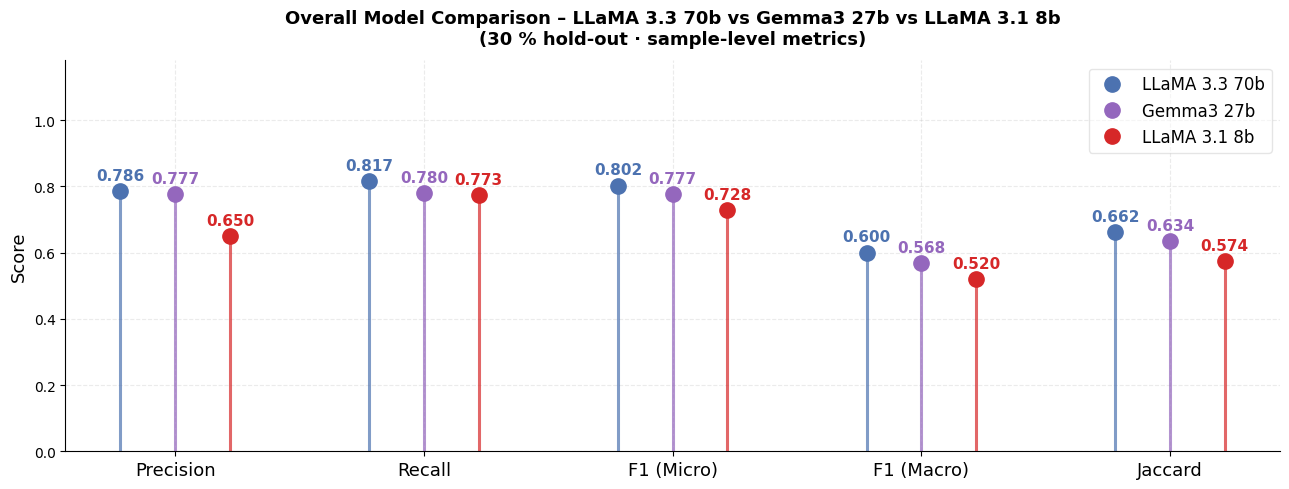

✅ Saved overall_three_model_comparison.png

Metric                  LLaMA 3.3 70b       Gemma3 27b     LLaMA 3.1 8b          Winner
--------------------------------------------------------------------------------
Precision                      0.7864           0.7770           0.6500  ← LLaMA 3.3 70b
Recall                         0.8165           0.7797           0.7730  ← LLaMA 3.3 70b
F1 (Micro)                     0.8018           0.7768           0.7280  ← LLaMA 3.3 70b
F1 (Macro)                     0.6000           0.5676           0.5200  ← LLaMA 3.3 70b
Jaccard                        0.6624           0.6340           0.5740  ← LLaMA 3.3 70b


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Overall metrics: LLaMA 3.3 70b vs Gemma3 27b vs LLaMA 3.1 8b ────────────
overall = pd.DataFrame({
    "Metric":        ["Precision", "Recall", "F1 (Micro)", "F1 (Macro)", "Jaccard"],
    "LLaMA 3.3 70b": [0.7864,      0.8165,   0.8018,       0.6000,       0.6624],
    "Gemma3 27b":    [0.7770,      0.7797,   0.7768,       0.5676,       0.6340],
    "LLaMA 3.1 8b":  [0.6500,      0.7730,   0.7280,       0.5200,       0.5740],
})

C_LLAMA70 = "#4C72B0"
C_GEMMA   = "#9467BD"
C_LLAMA8  = "#D62728"

models     = ["LLaMA 3.3 70b", "Gemma3 27b", "LLaMA 3.1 8b"]
colors     = [C_LLAMA70, C_GEMMA, C_LLAMA8]
metrics    = overall["Metric"].tolist()
offsets    = [-0.22, 0, 0.22]

plt.rcParams.update({"font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": "--"})

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics))

for model, color, offset in zip(models, colors, offsets):
    vals = overall[model].tolist()
    xpos = x + offset
    # stems
    ax.vlines(xpos, 0, vals, colors=color, linewidth=2.2, alpha=0.7)
    # dots
    ax.plot(xpos, vals, "o", color=color, markersize=11, label=model, zorder=5)
    # value labels
    for xi, v in zip(xpos, vals):
        ax.text(xi, v + 0.025, f"{v:.3f}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=13)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=13)
ax.set_title("Overall Model Comparison – LLaMA 3.3 70b vs Gemma3 27b vs LLaMA 3.1 8b\n(30 % hold-out · sample-level metrics)",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=12, framealpha=0.5)

plt.tight_layout()
plt.savefig(r"c:\Users\eggoni\Desktop\llm\overall_three_model_comparison.png", dpi=150)
plt.show()
print("✅ Saved overall_three_model_comparison.png")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Metric':<20}", end="")
for m in models:
    print(f"  {m:>15}", end="")
print(f"  {'Winner':>14}")
print("-" * 80)
for _, row in overall.iterrows():
    metric = row["Metric"]
    vals = {m: row[m] for m in models}
    winner = max(vals, key=vals.get)
    print(f"{metric:<20}", end="")
    for m in models:
        print(f"  {vals[m]:>15.4f}", end="")
    print(f"  {'← '+winner:>14}")

In [17]:
Jaccard Similarity: 0.574
Recall: 0.773
F1 Score: 0.706
Micro F1: 0.728
Precision: 0.650

SyntaxError: invalid syntax (3010836739.py, line 1)